In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [6]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [7]:
training_set = dataset[:'2016'].iloc[:,3:4].values
test_set = dataset['2017':].iloc[:,3:4].values

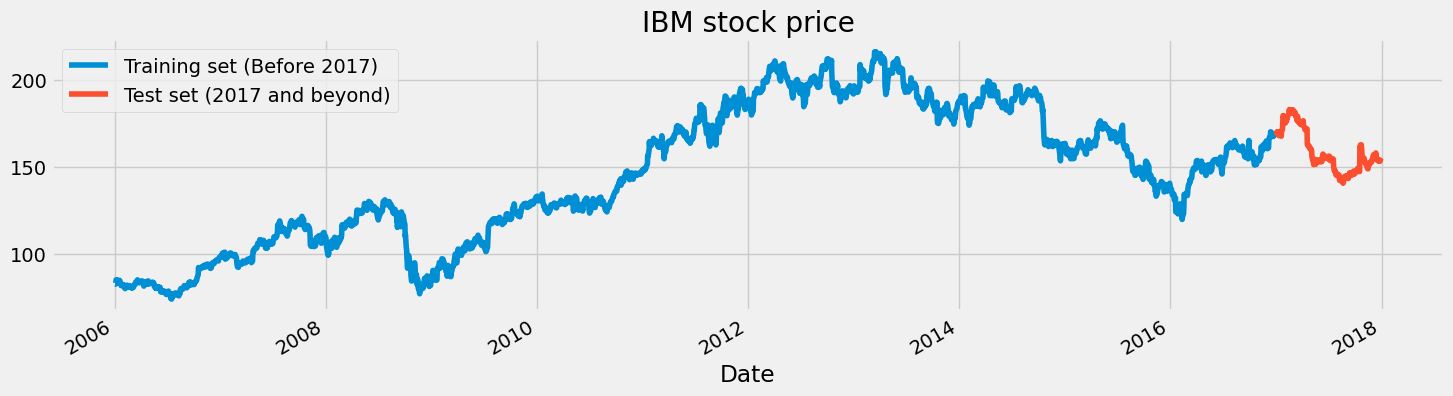

In [8]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [9]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [10]:
X_train = []
y_train = []
for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)


X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [11]:

regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))


regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units=1))

regressor.compile(optimizer='adam', loss='mean_absolute_error')

regressor.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - loss: 0.0995
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0525
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0480
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 0.0482
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0494
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0436
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.0425
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - loss: 0.0440
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - loss: 0.0386
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.0387
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 0.0375
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - loss: 0.0377
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0364
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 128ms/step - loss: 0.0375
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [12]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [13]:
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step


In [14]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu {:.2f}".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

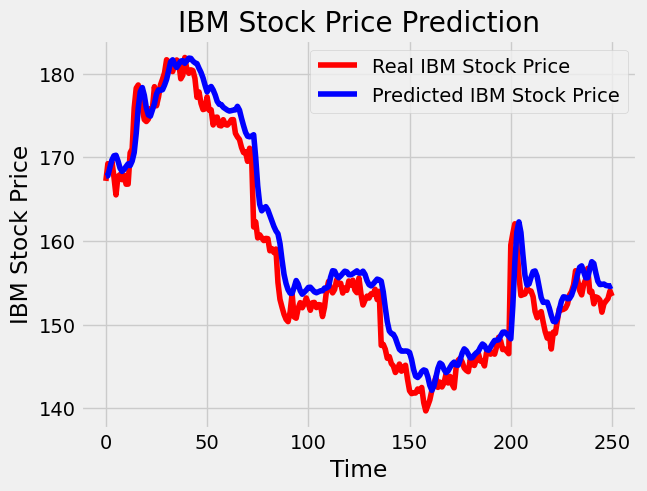

------------------------------
Błąd średniokwadratowy modelu 2.90
------------------------------
Średni błąd bezwzględny: 2.30
Średni błąd bezwzględny procentowy: 1.47%
------------------------------


In [15]:
plot_predictions(test_set, predicted_stock_price)

return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

In [16]:
regressorGRU = Sequential()

regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

regressorGRU.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - loss: 0.0176
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - loss: 0.0083
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - loss: 0.0074
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - loss: 0.0062
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - loss: 0.0053
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - loss: 0.0050
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - loss: 0.0041
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 155ms/step - loss: 0.0040
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - loss: 0.0040
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - loss: 0.0036
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - loss: 0.0035
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - loss: 0.0034
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - loss: 0.0032
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - loss: 0.0032
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 

In [17]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

regressor.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - loss: 0.0245 - val_loss: 0.0024
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0049 - val_loss: 0.0016
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.0050 - val_loss: 0.0017
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0043 - val_loss: 0.0014
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0048 - val_loss: 0.0053
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0042 - val_loss: 0.0014
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0038 - val_loss: 0.0022
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.0037 - val_loss: 0.0012
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.0034 - val_loss: 0.0018
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 12/100
77/77 ━━━━━━━━━━━━━━

Rozpoczynam trening ostatecznego modelu...
Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - loss: 0.0247 - val_loss: 0.0023
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.0055 - val_loss: 0.0022
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.0047 - val_loss: 0.0019
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - loss: 0.0041 - val_loss: 0.0020
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 0.0043 - val_loss: 0.0014
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.0039 - val_loss: 0.0015
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - loss: 0.0039 - val_loss: 0.0027
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.0034 - val_lo

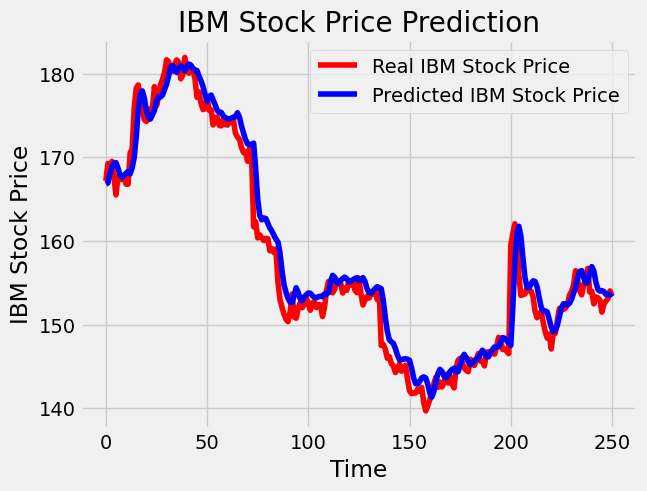

------------------------------
Błąd średniokwadratowy modelu 2.36
------------------------------
Średni błąd bezwzględny: 1.71
Średni błąd bezwzględny procentowy: 1.09%
------------------------------


In [18]:
regressor_final = Sequential()
regressor_final.add(Input(shape=(X_train.shape[1], 1)))
regressor_final.add(LSTM(units=50, return_sequences=True))
regressor_final.add(Dropout(0.2))
regressor_final.add(LSTM(units=50, return_sequences=True))
regressor_final.add(Dropout(0.2))
regressor_final.add(LSTM(units=50, return_sequences=True))
regressor_final.add(Dropout(0.2))
regressor_final.add(LSTM(units=50))
regressor_final.add(Dropout(0.2))
regressor_final.add(Dense(units=1))

regressor_final.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Rozpoczynam trening ostatecznego modelu...")
regressor_final.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

print("Obliczam predykcje...")
predicted_stock_price = regressor_final.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

plot_predictions(test_set, predicted_stock_price)
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

Rozpoczynam pełny trening...
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0180
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0087
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0083
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0067
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0060
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0056
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0050
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - loss: 0.0052
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - loss: 0.0043
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - loss: 0.0042
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.0039
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - loss: 0.0037
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0037
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 128ms/step - loss: 0.0034
Epoch 15/50
85

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step


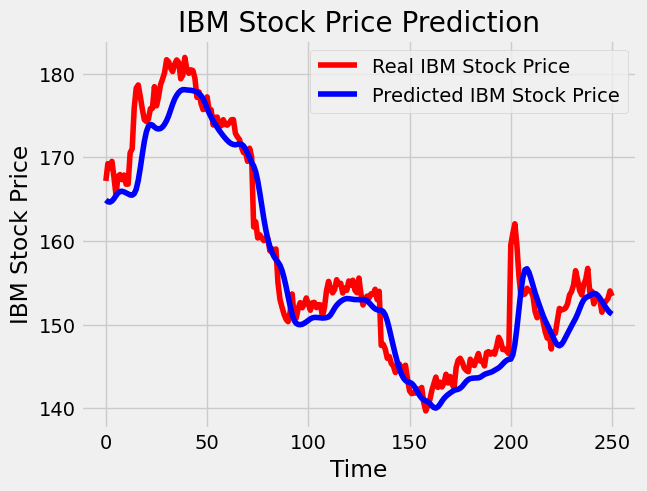

------------------------------
Błąd średniokwadratowy modelu 3.35
------------------------------
Średni błąd bezwzględny: 2.44
Średni błąd bezwzględny procentowy: 1.53%
------------------------------


In [19]:

regressor_final = Sequential()
regressor_final.add(Input(shape=(X_train.shape[1], 1)))
regressor_final.add(LSTM(units=50, return_sequences=True))
regressor_final.add(Dropout(0.2))
regressor_final.add(LSTM(units=50, return_sequences=True))
regressor_final.add(Dropout(0.2))
regressor_final.add(LSTM(units=50, return_sequences=True))
regressor_final.add(Dropout(0.2))
regressor_final.add(LSTM(units=50))
regressor_final.add(Dropout(0.2))
regressor_final.add(Dense(units=1))

regressor_final.compile(optimizer='rmsprop', loss='mean_squared_error')

print("Rozpoczynam pełny trening...")
regressor_final.fit(X_train, y_train, epochs=50, batch_size=32)

print("Obliczam predykcje...")
predicted_stock_price = regressor_final.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

plot_predictions(test_set, predicted_stock_price)
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)